# Hybrid LLM + Quantitative Bitcoin Trading Strategy

This notebook modifies the original Bitcoin trading-agent workflow into a **hybrid local-LLM + deterministic quantitative strategy**.

The design keeps actual order execution rule-based per candle, while using an open-source LLM through **Ollama** for:

- regime switching between **value investing / DCA** and **swing trading**
- contextual buy / sell / hold recommendation
- dynamic feature selection
- risk-size adjustment

> Educational backtesting code only. This is not financial advice and should be paper-tested before any real trading.


In [2]:
# Import necessary libraries

import json
import re
import time
import math
import warnings
from datetime import datetime, timedelta, timezone
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

np.random.seed(42)


## 1. Configurations

In [4]:
# Set up configurations

CONFIG = {
    # Data
    "product_id": "BTC-USD",
    "granularity": 86400,       # 86400 = daily candles on Coinbase public endpoint
    "days_back": 300,

    # Portfolio
    "initial_budget": 100000.0,
    "max_portfolio_drawdown_pause": 0.25,  # pause if total equity drops >= 25% from initial budget
    "fee_rate": 0.001,                     # simple transaction fee assumption, 0.1%

    # DCA / value investing
    "dca_budget_fraction": 0.75,
    "dca_buy_amount": 5000.0,
    "dca_drop_trigger_pct": 0.03,          # buy when close drops 3% from current DCA reference
    "dca_exit_rsi": 75.0,                  # trim if overheated
    "dca_exit_fraction": 0.75,

    # Swing trading
    "swing_budget_fraction": 0.25,
    "swing_buy_amount": 10000.0,
    "swing_max_open_positions": 10,
    "swing_atr_stop_multiple": 1.5,
    "swing_take_profit_atr_multiple": 1.0,
    "swing_trailing_stop": True,

    # LLM / Ollama
    "use_llm": True,
    "ollama_url": "http://localhost:11434/api/generate",
    "ollama_model": "llama3.2:1b",
    "ollama_timeout": 60,
    "llm_temperature": 0.1,
    "llm_every_n_candles": 25,              # lower value = more calls, slower backtest


    # LLM guardrails
    "min_llm_confidence_to_trade": 0.55,     # below this, LLM buy/sell is downgraded to hold
    "risk_multiplier_min": 0.10,             # hard lower clamp for LLM risk sizing
    "risk_multiplier_max": 1.00,             # hard upper clamp for LLM risk sizing
    "high_vol_atr_pct": 0.06,                # throttle risk when ATR / close is high
    "medium_vol_atr_pct": 0.04,              # modest throttle when ATR / close is elevated
    "soft_drawdown_throttle": 0.15,          # reduce risk before the hard 25% pause
    "regime_min_hold_candles": 5,            # prevent regime flipping every candle
    "min_candles_between_trades": 3,         # prevent overtrading
    "require_indicator_confirmation": True,  # LLM signal must agree with basic RSI/MACD/EMA checks

    # Trading warm-up
    "min_rows_before_trading": 50,
}

CONFIG

{'product_id': 'BTC-USD',
 'granularity': 86400,
 'days_back': 300,
 'initial_budget': 100000.0,
 'max_portfolio_drawdown_pause': 0.25,
 'fee_rate': 0.001,
 'dca_budget_fraction': 0.75,
 'dca_buy_amount': 5000.0,
 'dca_drop_trigger_pct': 0.03,
 'dca_exit_rsi': 75.0,
 'dca_exit_fraction': 0.75,
 'swing_budget_fraction': 0.25,
 'swing_buy_amount': 10000.0,
 'swing_max_open_positions': 10,
 'swing_atr_stop_multiple': 1.5,
 'swing_take_profit_atr_multiple': 1.0,
 'swing_trailing_stop': True,
 'use_llm': True,
 'ollama_url': 'http://localhost:11434/api/generate',
 'ollama_model': 'llama3.2:1b',
 'ollama_timeout': 60,
 'llm_temperature': 0.1,
 'llm_every_n_candles': 25,
 'min_llm_confidence_to_trade': 0.55,
 'risk_multiplier_min': 0.1,
 'risk_multiplier_max': 1.0,
 'high_vol_atr_pct': 0.06,
 'medium_vol_atr_pct': 0.04,
 'soft_drawdown_throttle': 0.15,
 'regime_min_hold_candles': 5,
 'min_candles_between_trades': 3,
 'require_indicator_confirmation': True,
 'min_rows_before_trading': 50}

## 2. Data loading

The notebook uses Coinbase public candle data by default. If the API is unavailable, load your own OHLCV CSV with columns: `time`, `open`, `high`, `low`, `close`, `volume`.


In [6]:
# Fetch BTC candles from Coinbase public API

def get_btc_historical_candles(product_id: str = "BTC-USD", granularity: int = 86400, days_back: int = 300) -> pd.DataFrame:
    """Fetch historical OHLCV candles from Coinbase Exchange public API.

    Coinbase returns rows as: [time, low, high, open, close, volume]
    """
    end_time = datetime.now(timezone.utc)
    start_time = end_time - timedelta(days=days_back)

    url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
    params = {
        "start": start_time.isoformat().replace("+00:00", "Z"),
        "end": end_time.isoformat().replace("+00:00", "Z"),
        "granularity": granularity,
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    rows = response.json()

    candles = []
    for row in rows:
        candles.append({
            "time": datetime.fromtimestamp(row[0], tz=timezone.utc),
            "low": float(row[1]),
            "high": float(row[2]),
            "open": float(row[3]),
            "close": float(row[4]),
            "volume": float(row[5]),
        })

    df = pd.DataFrame(candles).sort_values("time").reset_index(drop=True)
    return df


def load_candles_from_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True)
    required = {"time", "open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required columns: {sorted(missing)}")
    return df.sort_values("time").reset_index(drop=True)


## 3. Technical indicators and custom features


In [8]:
# Technical indicators + engineered features

def calculate_atr(df: pd.DataFrame, window: int = 14) -> pd.Series:
    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()


def calculate_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def calculate_macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> Tuple[pd.Series, pd.Series, pd.Series]:
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist


def prepare_feature_table(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy().sort_values("time").reset_index(drop=True)

    # Standard indicators
    df["ATR"] = calculate_atr(df, 14)
    df["rsi_14"] = calculate_rsi(df["close"], 14)
    df["sma_20"] = df["close"].rolling(20).mean()
    df["sma_50"] = df["close"].rolling(50).mean()
    df["sma_100"] = df["close"].rolling(100).mean()
    df["ema_20"] = df["close"].ewm(span=20, adjust=False).mean()
    df["ema_50"] = df["close"].ewm(span=50, adjust=False).mean()
    df["ema_100"] = df["close"].ewm(span=100, adjust=False).mean()
    df["macd"], df["macd_signal"], df["macd_hist"] = calculate_macd(df["close"])

    # Custom engineered features
    df["return_1"] = df["close"].pct_change(1)
    df["return_3"] = df["close"].pct_change(3)
    df["return_7"] = df["close"].pct_change(7)
    df["volatility_14"] = df["return_1"].rolling(14).std()
    df["atr_pct"] = df["ATR"] / df["close"]
    df["range_pct"] = (df["high"] - df["low"]) / df["close"]
    df["close_to_high_pct"] = (df["high"] - df["close"]) / df["close"]
    df["close_to_low_pct"] = (df["close"] - df["low"]) / df["close"]
    df["volume_z_20"] = (df["volume"] - df["volume"].rolling(20).mean()) / df["volume"].rolling(20).std()
    df["dist_ema20"] = (df["close"] - df["ema_20"]) / df["ema_20"]
    df["dist_ema50"] = (df["close"] - df["ema_50"]) / df["ema_50"]
    df["dist_ema100"] = (df["close"] - df["ema_100"]) / df["ema_100"]
    df["rolling_peak"] = df["close"].cummax()
    df["drawdown_from_peak"] = (df["rolling_peak"] - df["close"]) / df["rolling_peak"]
    df["momentum_score"] = (
        np.sign(df["return_3"].fillna(0)) +
        np.sign(df["macd_hist"].fillna(0)) +
        np.sign(df["dist_ema20"].fillna(0))
    )

    return df


def feature_snapshot(row: pd.Series) -> Dict[str, float]:
    """Compact feature dictionary sent to the LLM."""
    cols = [
        "close", "ATR", "atr_pct", "rsi_14", "macd", "macd_signal", "macd_hist",
        "sma_20", "sma_50", "ema_20", "ema_50", "ema_100", "return_1", "return_3", "return_7",
        "volatility_14", "range_pct", "volume_z_20", "dist_ema20", "dist_ema50", "dist_ema100",
        "drawdown_from_peak", "momentum_score",
    ]
    snap = {}
    for c in cols:
        val = row.get(c, np.nan)
        snap[c] = None if pd.isna(val) else float(val)
    return snap


## 4. Ollama LLM decision module

The LLM returns structured JSON. If Ollama is unavailable, slow, or returns malformed JSON, the notebook automatically falls back to deterministic heuristics.


In [10]:
# LLM decision module with robust JSON parsing and fallback


VALID_REGIMES = {"value_investing", "swing_trading", "hold"}
VALID_SIGNALS = {"buy", "sell", "hold"}


def extract_json_object(text: str) -> Dict[str, Any]:
    """Extract the first JSON object from an LLM response."""
    if not isinstance(text, str):
        raise ValueError("LLM response is not text")

    # Remove markdown fences if present
    cleaned = re.sub(r"```(?:json)?", "", text, flags=re.IGNORECASE).replace("```", "").strip()

    # Try direct parse first
    try:
        return json.loads(cleaned)
    except Exception:
        pass

    # Then extract first {...} block
    match = re.search(r"\{.*\}", cleaned, flags=re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in LLM response: {text[:300]}")

    return json.loads(match.group(0))


def normalize_llm_decision(decision: Dict[str, Any]) -> Dict[str, Any]:
    regime = str(decision.get("regime", "hold")).strip().lower()
    signal = str(decision.get("signal", "hold")).strip().lower()

    if regime not in VALID_REGIMES:
        regime = "hold"
    if signal not in VALID_SIGNALS:
        signal = "hold"

    selected_features = decision.get("selected_features", [])
    if not isinstance(selected_features, list):
        selected_features = []
    selected_features = [str(x) for x in selected_features[:8]]

    try:
        risk_multiplier = float(decision.get("risk_multiplier", 0.5))
    except Exception:
        risk_multiplier = 0.5
    risk_multiplier = float(np.clip(risk_multiplier, 0.0, 1.0))

    try:
        confidence = float(decision.get("confidence", 0.5))
    except Exception:
        confidence = 0.5
    confidence = float(np.clip(confidence, 0.0, 1.0))

    return {
        "regime": regime,
        "signal": signal,
        "selected_features": selected_features,
        "risk_multiplier": risk_multiplier,
        "confidence": confidence,
        "reason": str(decision.get("reason", ""))[:500],
        "source": decision.get("source", "llm"),
    }


def heuristic_decision(row: pd.Series) -> Dict[str, Any]:
    """Fallback regime/signal/risk logic when Ollama is unavailable."""
    close = float(row["close"])
    ema_20 = row.get("ema_20", np.nan)
    ema_50 = row.get("ema_50", np.nan)
    ema_100 = row.get("ema_100", np.nan)
    rsi = row.get("rsi_14", np.nan)
    macd_hist = row.get("macd_hist", np.nan)
    drawdown = row.get("drawdown_from_peak", np.nan)
    atr_pct = row.get("atr_pct", np.nan)

    # Regime selection
    if pd.notna(drawdown) and drawdown >= 0.15:
        regime = "value_investing"
    elif pd.notna(ema_100) and close < ema_100:
        regime = "value_investing"
    elif pd.notna(ema_20) and pd.notna(ema_50) and close > ema_50 and ema_20 > ema_50:
        regime = "swing_trading"
    else:
        regime = "hold"

    # Signal selection
    signal = "hold"
    if regime == "value_investing" and pd.notna(rsi) and rsi < 45:
        signal = "buy"
    elif regime == "swing_trading" and pd.notna(macd_hist) and macd_hist > 0 and pd.notna(rsi) and 45 <= rsi <= 72:
        signal = "buy"
    elif pd.notna(rsi) and rsi > 78:
        signal = "sell"

    # Risk adjustment: reduce size when volatility is high
    risk_multiplier = 0.6
    if pd.notna(atr_pct):
        if atr_pct > 0.06:
            risk_multiplier = 0.25
        elif atr_pct > 0.04:
            risk_multiplier = 0.4
        elif atr_pct < 0.025:
            risk_multiplier = 0.8

    return normalize_llm_decision({
        "regime": regime,
        "signal": signal,
        "selected_features": ["rsi_14", "macd_hist", "ema_20", "ema_50", "ema_100", "atr_pct", "drawdown_from_peak"],
        "risk_multiplier": risk_multiplier,
        "confidence": 0.55,
        "reason": "Deterministic fallback based on RSI, MACD, EMA trend, drawdown, and ATR%. ",
        "source": "heuristic_fallback",
    })


def call_ollama_decision(row: pd.Series, config: Dict[str, Any]) -> Dict[str, Any]:
    """Ask Ollama for regime, signal, selected features, and risk sizing."""
    if not config.get("use_llm", True):
        return heuristic_decision(row)

    snap = feature_snapshot(row)
    prompt = f"""
You are a conservative crypto trading risk assistant.

Return ONLY valid JSON with this schema:
{{
  "regime": "value_investing" | "swing_trading" | "hold",
  "signal": "buy" | "sell" | "hold",
  "selected_features": ["feature_name_1", "feature_name_2"],
  "risk_multiplier": number between 0 and 1,
  "confidence": number between 0 and 1,
  "reason": "brief reason"
}}

Rules:
- Use value_investing when BTC is in a large drawdown, below long-term trend, or RSI is weak/oversold.
- Use swing_trading when trend and momentum are positive.
- Use hold when conditions are unclear or risk is high.
- Lower risk_multiplier when ATR% or volatility is high.
- Do not recommend large risk when drawdown or ATR% is high.

Current candle features:
{json.dumps(snap, indent=2)}
""".strip()

    payload = {
        "model": config.get("ollama_model", "llama3.2:3b"),
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": config.get("llm_temperature", 0.1)},
    }

    try:
        resp = requests.post(config["ollama_url"], json=payload, timeout=config.get("ollama_timeout", 60))
        resp.raise_for_status()
        data = resp.json()
        raw_text = data.get("response", "")
        decision = extract_json_object(raw_text)
        normalized = normalize_llm_decision(decision)
        normalized["source"] = "ollama"
        return normalized
    except Exception as e:
        fallback = heuristic_decision(row)
        fallback["reason"] = f"Ollama failed; using fallback. Error: {e}"
        fallback["source"] = "heuristic_fallback_after_llm_error"
        return fallback


## 4B. LLM guardrails

This layer treats the LLM as an advisor, not an executor. It validates JSON-like decisions, clamps risk, downgrades low-confidence outputs, prevents regime flipping, throttles high-volatility/drawdown periods, and applies simple indicator confirmation before the rule-based per-candle engine can trade.


In [12]:
# LLM guardrails

ALLOWED_LLM_FEATURES = {
    "close", "volume", "returns_1", "returns_3", "returns_7",
    "volatility_7", "volatility_14", "drawdown_from_peak",
    "sma_20", "sma_50", "ema_20", "ema_50", "ema_100",
    "rsi_14", "macd", "macd_signal", "macd_hist",
    "ATR", "atr_pct", "volume_zscore", "price_vs_sma_50", "price_vs_ema_100",
}


def make_safe_hold_decision(reason: str, source: str = "guardrail") -> Dict[str, Any]:
    """Return a conservative no-trade decision."""
    return {
        "regime": "hold",
        "signal": "hold",
        "selected_features": [],
        "risk_multiplier": 0.0,
        "confidence": 0.0,
        "reason": reason[:500],
        "source": source,
        "guardrails_applied": [reason],
    }


def indicator_confirmation(row: pd.Series, decision: Dict[str, Any]) -> Tuple[bool, str]:
    """Require a minimal technical-indicator sanity check before honoring LLM buy/sell calls."""
    signal = decision.get("signal", "hold")
    regime = decision.get("regime", "hold")

    if signal == "hold":
        return True, "hold requires no confirmation"

    close = float(row.get("close", np.nan))
    rsi = row.get("rsi_14", np.nan)
    macd_hist = row.get("macd_hist", np.nan)
    ema_20 = row.get("ema_20", np.nan)
    ema_50 = row.get("ema_50", np.nan)
    ema_100 = row.get("ema_100", np.nan)

    if any(pd.isna(x) for x in [close, rsi, macd_hist]):
        return False, "missing required indicator values"

    if signal == "buy" and regime == "swing_trading":
        trend_ok = pd.notna(ema_20) and pd.notna(ema_50) and close > ema_50 and ema_20 > ema_50
        momentum_ok = macd_hist > 0 and 45 <= rsi <= 75
        return bool(trend_ok and momentum_ok), "swing buy needs close>EMA50, EMA20>EMA50, MACD hist>0, and RSI 45-75"

    if signal == "buy" and regime == "value_investing":
        value_ok = (rsi <= 55) or (pd.notna(ema_100) and close < ema_100)
        return bool(value_ok), "DCA/value buy needs RSI<=55 or price below EMA100"

    if signal == "sell":
        sell_ok = (rsi >= 70) or (macd_hist < 0) or (pd.notna(ema_20) and close < ema_20)
        return bool(sell_ok), "sell needs RSI>=70, MACD hist<0, or close<EMA20"

    return True, "no extra confirmation rule"


def apply_llm_guardrails(row: pd.Series, raw_decision: Dict[str, Any], portfolio: Dict[str, Any], config: Dict[str, Any]) -> Dict[str, Any]:
    """
    Validate and sanitize an LLM/fallback decision before it can affect trading.

    Guardrails included:
    1. Strict schema/value normalization.
    2. Feature whitelist.
    3. Confidence gating.
    4. Risk multiplier clamping.
    5. Volatility and drawdown throttling.
    6. Regime persistence to prevent flip-flopping.
    7. Indicator confirmation.
    8. Trade cooldown.
    9. Hard pause respect.
    """
    applied = []

    try:
        decision = normalize_llm_decision(raw_decision)
    except Exception as exc:
        decision = make_safe_hold_decision(f"invalid LLM decision schema: {exc}")
        applied.append("invalid_schema_safe_hold")

    # Whitelist selected features so the LLM cannot invent arbitrary fields that later code trusts.
    original_features = decision.get("selected_features", [])
    filtered_features = [f for f in original_features if f in ALLOWED_LLM_FEATURES]
    if len(filtered_features) != len(original_features):
        applied.append("feature_whitelist_filtered")
    decision["selected_features"] = filtered_features[:8]

    # Clamp confidence and risk to safe numeric ranges.
    confidence = float(np.clip(decision.get("confidence", 0.0), 0.0, 1.0))
    risk_min = float(config.get("risk_multiplier_min", 0.10))
    risk_max = float(config.get("risk_multiplier_max", 1.00))
    risk_multiplier = float(np.clip(decision.get("risk_multiplier", 0.0), risk_min, risk_max))
    decision["confidence"] = confidence
    decision["risk_multiplier"] = risk_multiplier

    # Low confidence cannot trigger new buy/sell decisions.
    min_conf = float(config.get("min_llm_confidence_to_trade", 0.55))
    if confidence < min_conf and decision.get("signal") in {"buy", "sell"}:
        decision["signal"] = "hold"
        decision["risk_multiplier"] = min(decision["risk_multiplier"], 0.25)
        applied.append(f"low_confidence_to_hold<{min_conf}")

    # Volatility-aware throttle using ATR%.
    atr_pct = row.get("atr_pct", np.nan)
    if pd.notna(atr_pct):
        if atr_pct >= float(config.get("high_vol_atr_pct", 0.06)):
            decision["risk_multiplier"] *= 0.50
            applied.append("high_atr_volatility_50pct_risk")
        elif atr_pct >= float(config.get("medium_vol_atr_pct", 0.04)):
            decision["risk_multiplier"] *= 0.75
            applied.append("medium_atr_volatility_75pct_risk")

    # Portfolio drawdown throttle before the hard pause threshold.
    current_equity = mark_to_market_value(portfolio, float(row["close"]))
    drawdown = max(0.0, (portfolio["initial_budget"] - current_equity) / portfolio["initial_budget"])
    if drawdown >= float(config.get("max_portfolio_drawdown_pause", 0.25)):
        decision = make_safe_hold_decision("hard drawdown pause threshold reached", source="guardrail_hard_pause")
        applied.append("hard_drawdown_safe_hold")
    elif drawdown >= float(config.get("soft_drawdown_throttle", 0.15)):
        decision["risk_multiplier"] *= 0.50
        applied.append("soft_drawdown_50pct_risk")

    # Regime persistence: avoid switching regimes every candle.
    current_regime = portfolio.get("current_regime", "hold")
    regime_duration = int(portfolio.get("regime_duration", 0))
    min_hold = int(config.get("regime_min_hold_candles", 5))
    proposed_regime = decision.get("regime", "hold")

    if current_regime != "hold" and proposed_regime != current_regime and regime_duration < min_hold:
        decision["regime"] = current_regime
        decision["signal"] = "hold"
        decision["risk_multiplier"] *= 0.50
        applied.append(f"regime_persistence_hold_{regime_duration}_of_{min_hold}")
    else:
        if proposed_regime == current_regime:
            portfolio["regime_duration"] = regime_duration + 1
        else:
            portfolio["current_regime"] = proposed_regime
            portfolio["regime_duration"] = 1

    # Indicator confirmation: LLM must agree with simple technical rules.
    if config.get("require_indicator_confirmation", True):
        ok, why = indicator_confirmation(row, decision)
        if not ok and decision.get("signal") in {"buy", "sell"}:
            decision["signal"] = "hold"
            decision["risk_multiplier"] *= 0.50
            applied.append(f"indicator_confirmation_failed: {why}")

    # Cooldown after any trade to reduce churn.
    idx = int(row.name) if isinstance(row.name, (int, np.integer)) else 0
    candles_since_trade = idx - int(portfolio.get("last_trade_idx", -10**9))
    min_gap = int(config.get("min_candles_between_trades", 3))
    if candles_since_trade < min_gap and decision.get("signal") in {"buy", "sell"}:
        decision["signal"] = "hold"
        decision["risk_multiplier"] *= 0.50
        applied.append(f"trade_cooldown_{candles_since_trade}_of_{min_gap}")

    # Re-clamp after throttles.
    decision["risk_multiplier"] = float(np.clip(decision.get("risk_multiplier", 0.0), 0.0, risk_max))
    decision["guardrails_applied"] = applied

    if applied:
        portfolio["guardrail_events"].append({
            "time": row["time"],
            "idx": idx,
            "close": float(row["close"]),
            "raw_regime": raw_decision.get("regime", None),
            "raw_signal": raw_decision.get("signal", None),
            "final_regime": decision.get("regime"),
            "final_signal": decision.get("signal"),
            "confidence": decision.get("confidence"),
            "risk_multiplier": decision.get("risk_multiplier"),
            "guardrails_applied": "; ".join(applied),
        })

    return decision


## 5. Portfolio and execution helpers


In [14]:
# Portfolio accounting helpers

def initialize_portfolio(df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, Any]:
    initial_budget = float(config["initial_budget"])
    return {
        "initial_budget": initial_budget,
        "remaining_cash": initial_budget,
        "dca_budget_limit": initial_budget * float(config["dca_budget_fraction"]),
        "swing_budget_limit": initial_budget * float(config["swing_budget_fraction"]),
        "dca_capital_deployed": 0.0,
        "swing_capital_deployed": 0.0,
        "dca_reference_price": float(df.loc[0, "close"]),
        "open_positions": [],
        "buy_events": [],
        "sell_events": [],
        "equity_curve": [],
        "llm_decisions": [],
        "guardrail_events": [],
        "current_regime": "hold",
        "regime_duration": 0,
        "last_trade_idx": -10**9,
        "paused": False,
        "pause_reason": None,
    }


def active_positions(portfolio: Dict[str, Any], position_type: Optional[str] = None) -> List[Dict[str, Any]]:
    positions = [p for p in portfolio["open_positions"] if p.get("btc_remaining", 0.0) > 1e-12]
    if position_type is not None:
        positions = [p for p in positions if p.get("type") == position_type]
    return positions


def mark_to_market_value(portfolio: Dict[str, Any], current_price: float) -> float:
    btc_value = sum(p["btc_remaining"] * current_price for p in active_positions(portfolio))
    return float(portfolio["remaining_cash"]) + btc_value


def unrealized_pnl(portfolio: Dict[str, Any], current_price: float) -> float:
    return sum((current_price - p["entry_price"]) * p["btc_remaining"] for p in active_positions(portfolio))


def realized_pnl(portfolio: Dict[str, Any]) -> float:
    return float(sum(e.get("pnl", 0.0) for e in portfolio["sell_events"]))


def record_equity(row: pd.Series, portfolio: Dict[str, Any]) -> None:
    price = float(row["close"])
    equity = mark_to_market_value(portfolio, price)
    portfolio["equity_curve"].append({
        "time": row["time"],
        "close": price,
        "remaining_cash": float(portfolio["remaining_cash"]),
        "total_btc": sum(p["btc_remaining"] for p in active_positions(portfolio)),
        "total_equity": equity,
        "unrealized_pnl": unrealized_pnl(portfolio, price),
        "realized_pnl": realized_pnl(portfolio),
        "drawdown_from_initial_budget": max(0.0, (portfolio["initial_budget"] - equity) / portfolio["initial_budget"]),
        "paused": portfolio["paused"],
    })


def update_pause_state(row: pd.Series, portfolio: Dict[str, Any], config: Dict[str, Any]) -> None:
    equity = mark_to_market_value(portfolio, float(row["close"]))
    dd = (portfolio["initial_budget"] - equity) / portfolio["initial_budget"]
    if dd >= float(config["max_portfolio_drawdown_pause"]):
        portfolio["paused"] = True
        portfolio["pause_reason"] = f"Portfolio value dropped {dd:.2%} from initial budget. New entries paused."


def reduce_capital_deployed(portfolio: Dict[str, Any], position: Dict[str, Any], sold_fraction: float) -> None:
    amount = position["initial_usd"] * sold_fraction
    if position["type"] == "dca":
        portfolio["dca_capital_deployed"] = max(0.0, portfolio["dca_capital_deployed"] - amount)
    elif position["type"] == "swing":
        portfolio["swing_capital_deployed"] = max(0.0, portfolio["swing_capital_deployed"] - amount)


## 6. Entry and exit rules

The LLM is a **meta-decision layer**. Execution remains deterministic and auditable:

- DCA entry: buy after a configurable price drop from DCA reference.
- DCA exit: trim if RSI is overheated or LLM says sell.
- Swing entry: requires LLM/fallback `swing_trading + buy` plus momentum confirmation.
- Swing exit: ATR stop-loss, ATR take-profit, trailing ATR stop, bearish MACD, or LLM sell.
- Pause rule: no new buys after 25% portfolio drawdown.


In [16]:
# Trade execution functions

def execute_buy(row: pd.Series, portfolio: Dict[str, Any], position_type: str, usd_amount: float, reason: str, config: Dict[str, Any]) -> bool:
    if portfolio["paused"]:
        return False

    price = float(row["close"])
    atr = row.get("ATR", np.nan)
    fee_rate = float(config.get("fee_rate", 0.0))
    usd_amount = float(min(usd_amount, portfolio["remaining_cash"]))
    if usd_amount <= 0:
        return False

    # Budget caps
    if position_type == "dca":
        remaining_cap = portfolio["dca_budget_limit"] - portfolio["dca_capital_deployed"]
    elif position_type == "swing":
        remaining_cap = portfolio["swing_budget_limit"] - portfolio["swing_capital_deployed"]
    else:
        raise ValueError("position_type must be 'dca' or 'swing'")

    usd_amount = min(usd_amount, remaining_cap, portfolio["remaining_cash"])
    if usd_amount <= 0:
        return False

    fee = usd_amount * fee_rate
    net_usd = usd_amount - fee
    btc_amount = net_usd / price

    stop_loss = None
    take_profit = None
    if position_type == "swing" and pd.notna(atr):
        stop_loss = price - float(config["swing_atr_stop_multiple"]) * float(atr)
        take_profit = price + float(config["swing_take_profit_atr_multiple"]) * float(atr)

    position = {
        "id": f"{position_type}_{pd.Timestamp(row['time']).strftime('%Y%m%d%H%M%S')}_{len(portfolio['open_positions'])+1}",
        "type": position_type,
        "entry_time": row["time"],
        "entry_price": price,
        "initial_usd": usd_amount,
        "fee_entry": fee,
        "btc_initial": btc_amount,
        "btc_remaining": btc_amount,
        "stop_loss": stop_loss,
        "take_profit": take_profit,
        "highest_price_seen": price,
        "entry_reason": reason,
    }

    portfolio["open_positions"].append(position)
    portfolio["remaining_cash"] -= usd_amount
    if position_type == "dca":
        portfolio["dca_capital_deployed"] += usd_amount
        portfolio["dca_reference_price"] = price
    else:
        portfolio["swing_capital_deployed"] += usd_amount

    portfolio["last_trade_idx"] = int(row.name) if isinstance(row.name, (int, np.integer)) else portfolio.get("last_trade_idx", -10**9)

    portfolio["buy_events"].append({
        "time": row["time"],
        "type": position_type,
        "position_id": position["id"],
        "price": price,
        "usd_spent": usd_amount,
        "fee": fee,
        "btc_bought": btc_amount,
        "stop_loss": stop_loss,
        "take_profit": take_profit,
        "remaining_cash": portfolio["remaining_cash"],
        "reason": reason,
    })
    return True


def execute_sell(row: pd.Series, portfolio: Dict[str, Any], position: Dict[str, Any], btc_to_sell: float, exit_price: float, reason: str, config: Dict[str, Any]) -> bool:
    btc_to_sell = float(min(btc_to_sell, position["btc_remaining"]))
    if btc_to_sell <= 1e-12:
        return False

    fee_rate = float(config.get("fee_rate", 0.0))
    gross = btc_to_sell * exit_price
    fee = gross * fee_rate
    net = gross - fee
    pnl = net - (btc_to_sell * position["entry_price"])
    sold_fraction = btc_to_sell / max(position["btc_initial"], 1e-12)

    position["btc_remaining"] -= btc_to_sell
    portfolio["remaining_cash"] += net
    reduce_capital_deployed(portfolio, position, sold_fraction)

    portfolio["last_trade_idx"] = int(row.name) if isinstance(row.name, (int, np.integer)) else portfolio.get("last_trade_idx", -10**9)

    portfolio["sell_events"].append({
        "time": row["time"],
        "type": position["type"],
        "position_id": position["id"],
        "entry_time": position["entry_time"],
        "entry_price": position["entry_price"],
        "exit_price": float(exit_price),
        "btc_sold": btc_to_sell,
        "gross_usd": gross,
        "fee": fee,
        "net_usd": net,
        "pnl": pnl,
        "remaining_cash": portfolio["remaining_cash"],
        "reason": reason,
    })
    return True


def process_swing_exits(row: pd.Series, portfolio: Dict[str, Any], llm_decision: Dict[str, Any], config: Dict[str, Any]) -> None:
    low = float(row["low"])
    high = float(row["high"])
    close = float(row["close"])
    atr = row.get("ATR", np.nan)

    for pos in list(active_positions(portfolio, "swing")):
        pos["highest_price_seen"] = max(float(pos.get("highest_price_seen", pos["entry_price"])), high)

        # Optional ATR trailing stop
        if config.get("swing_trailing_stop", True) and pd.notna(atr):
            trailing_stop = pos["highest_price_seen"] - float(config["swing_atr_stop_multiple"]) * float(atr)
            if pos.get("stop_loss") is None:
                pos["stop_loss"] = trailing_stop
            else:
                pos["stop_loss"] = max(float(pos["stop_loss"]), trailing_stop)

        stop_hit = pos.get("stop_loss") is not None and low <= float(pos["stop_loss"])
        target_hit = pos.get("take_profit") is not None and high >= float(pos["take_profit"])
        bearish_exit = pd.notna(row.get("macd_hist", np.nan)) and row["macd_hist"] < 0 and close < row.get("ema_20", close)
        llm_sell = llm_decision.get("signal") == "sell"

        # Conservative assumption: if stop and target hit same candle, stop happens first.
        if stop_hit:
            execute_sell(row, portfolio, pos, pos["btc_remaining"], float(pos["stop_loss"]), "swing_atr_stop_loss", config)
        elif target_hit:
            execute_sell(row, portfolio, pos, pos["btc_remaining"], float(pos["take_profit"]), "swing_atr_take_profit", config)
        elif bearish_exit:
            execute_sell(row, portfolio, pos, pos["btc_remaining"], close, "swing_bearish_macd_exit", config)
        elif llm_sell:
            execute_sell(row, portfolio, pos, pos["btc_remaining"], close, "swing_llm_sell_exit", config)


def process_dca_exits(row: pd.Series, portfolio: Dict[str, Any], llm_decision: Dict[str, Any], config: Dict[str, Any]) -> None:
    close = float(row["close"])
    rsi = row.get("rsi_14", np.nan)
    should_trim = (pd.notna(rsi) and rsi >= float(config["dca_exit_rsi"])) or llm_decision.get("signal") == "sell"
    if not should_trim:
        return

    for pos in list(active_positions(portfolio, "dca")):
        btc_to_sell = pos["btc_remaining"] * float(config["dca_exit_fraction"])
        reason = "dca_overheated_rsi_trim" if pd.notna(rsi) and rsi >= float(config["dca_exit_rsi"]) else "dca_llm_sell_trim"
        execute_sell(row, portfolio, pos, btc_to_sell, close, reason, config)


def process_entries(row: pd.Series, portfolio: Dict[str, Any], llm_decision: Dict[str, Any], config: Dict[str, Any]) -> None:
    if portfolio["paused"]:
        return

    close = float(row["close"])
    risk_multiplier = float(llm_decision.get("risk_multiplier", 0.5))
    regime = llm_decision.get("regime", "hold")
    signal = llm_decision.get("signal", "hold")

    # Update DCA reference upward when market makes a new higher close.
    if close > portfolio["dca_reference_price"]:
        portfolio["dca_reference_price"] = close

    # DCA entry: price drops from reference and LLM/fallback is not explicitly bearish against buying.
    dca_drop = (portfolio["dca_reference_price"] - close) / max(portfolio["dca_reference_price"], 1e-12)
    if regime == "value_investing" and signal in {"buy", "hold"} and dca_drop >= float(config["dca_drop_trigger_pct"]):
        amount = float(config["dca_buy_amount"]) * max(risk_multiplier, 0.25)
        execute_buy(row, portfolio, "dca", amount, f"DCA drop trigger: {dca_drop:.2%}; LLM regime={regime}, signal={signal}", config)

    # Swing entry: LLM/fallback says swing + buy, with rule-based trend confirmation.
    trend_ok = close > row.get("ema_50", close) and row.get("ema_20", close) > row.get("ema_50", close)
    momentum_ok = row.get("macd_hist", -1) > 0 and 45 <= row.get("rsi_14", 50) <= 75
    max_positions_ok = len(active_positions(portfolio, "swing")) < int(config["swing_max_open_positions"])

    if regime == "swing_trading" and signal == "buy" and trend_ok and momentum_ok and max_positions_ok:
        amount = float(config["swing_buy_amount"]) * risk_multiplier
        execute_buy(row, portfolio, "swing", amount, "Swing entry: LLM buy + trend/MACD/RSI confirmation", config)


## 7. Per-candle strategy loop


In [18]:
# Per-candle execution loop

def run_hybrid_llm_quant_strategy(df: pd.DataFrame, config: Dict[str, Any]) -> Tuple[Dict[str, Any], pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.copy().sort_values("time").reset_index(drop=True)
    portfolio = initialize_portfolio(df, config)

    last_decision = heuristic_decision(df.iloc[0])

    for idx, row in df.iterrows():
        # Warm-up: record equity but do not trade before indicators stabilize.
        if idx < int(config["min_rows_before_trading"]):
            record_equity(row, portfolio)
            continue

        # Get LLM decision every N candles; otherwise reuse latest decision.
        # Then pass it through guardrails before the execution engine sees it.
        if idx % int(config["llm_every_n_candles"]) == 0:
            raw_decision = call_ollama_decision(row, config)
        else:
            raw_decision = last_decision

        last_decision = apply_llm_guardrails(row, raw_decision, portfolio, config)

        decision_record = dict(last_decision)
        decision_record.update({"time": row["time"], "idx": idx, "close": float(row["close"])})
        portfolio["llm_decisions"].append(decision_record)

        # 1. Always process exits first.
        process_swing_exits(row, portfolio, last_decision, config)
        process_dca_exits(row, portfolio, last_decision, config)

        # 2. Check risk pause after exits and before new entries.
        update_pause_state(row, portfolio, config)

        # 3. Process new entries only if not paused.
        process_entries(row, portfolio, last_decision, config)

        # 4. Re-check pause and record equity.
        update_pause_state(row, portfolio, config)
        record_equity(row, portfolio)

    equity_df = pd.DataFrame(portfolio["equity_curve"])
    buys_df = pd.DataFrame(portfolio["buy_events"])
    sells_df = pd.DataFrame(portfolio["sell_events"])
    llm_df = pd.DataFrame(portfolio["llm_decisions"])
    guardrail_df = pd.DataFrame(portfolio["guardrail_events"])
    return portfolio, equity_df, buys_df, sells_df, llm_df, guardrail_df


## 8. Performance summary and plots


In [20]:
# Performance analysis and plotting

def summarize_performance(portfolio: Dict[str, Any], equity_df: pd.DataFrame, buys_df: pd.DataFrame, sells_df: pd.DataFrame) -> Dict[str, Any]:
    if equity_df.empty:
        return {}
    initial = float(portfolio["initial_budget"])
    final_equity = float(equity_df["total_equity"].iloc[-1])
    running_peak = equity_df["total_equity"].cummax()
    max_dd = ((running_peak - equity_df["total_equity"]) / running_peak).max()

    return {
        "initial_budget": initial,
        "final_equity": final_equity,
        "total_return_pct": (final_equity / initial - 1.0) * 100,
        "max_drawdown_pct": float(max_dd) * 100,
        "remaining_cash": float(portfolio["remaining_cash"]),
        "total_open_btc": sum(p["btc_remaining"] for p in active_positions(portfolio)),
        "realized_pnl": realized_pnl(portfolio),
        "num_buys": 0 if buys_df.empty else len(buys_df),
        "num_sells": 0 if sells_df.empty else len(sells_df),
        "paused": portfolio["paused"],
        "pause_reason": portfolio["pause_reason"],
    }


def plot_equity_curve(equity_df: pd.DataFrame) -> None:
    if equity_df.empty:
        print("No equity data to plot.")
        return
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(equity_df["time"]), equity_df["total_equity"])
    plt.title("Total Portfolio Equity")
    plt.xlabel("Time")
    plt.ylabel("Equity, USD")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_price_with_trades(df: pd.DataFrame, buys_df: pd.DataFrame, sells_df: pd.DataFrame) -> None:
    plt.figure(figsize=(13, 6))
    plt.plot(pd.to_datetime(df["time"]), df["close"], label="BTC close")

    if not buys_df.empty:
        plt.scatter(pd.to_datetime(buys_df["time"]), buys_df["price"], marker="^", label="Buy")
    if not sells_df.empty:
        plt.scatter(pd.to_datetime(sells_df["time"]), sells_df["exit_price"], marker="v", label="Sell")

    plt.title("BTC Price with Strategy Trades")
    plt.xlabel("Time")
    plt.ylabel("BTC Price, USD")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def accounting_check(equity_df: pd.DataFrame, tolerance: float = 1e-6) -> pd.DataFrame:
    """Check that equity = cash + BTC market value. Useful for catching accounting bugs."""
    out = equity_df.copy()
    out["btc_market_value"] = out["total_btc"] * out["close"]
    out["recomputed_equity"] = out["remaining_cash"] + out["btc_market_value"]
    out["equity_diff"] = out["total_equity"] - out["recomputed_equity"]
    return out[out["equity_diff"].abs() > tolerance]


## 9. Run the notebook

Make sure Ollama is installed and the model is pulled if you want true local LLM decisions:

```bash
ollama pull llama3.2:3b
ollama serve
```

If Ollama is not running, the strategy still runs using the heuristic fallback.


In [22]:
# Execute workflow

# 1. Download candles
raw_df = get_btc_historical_candles(
    product_id=CONFIG["product_id"],
    granularity=CONFIG["granularity"],
    days_back=CONFIG["days_back"],
)

# 2. Build indicators/features
df = prepare_feature_table(raw_df)
display(df.tail())

# 3. Run strategy
portfolio, equity_df, buys_df, sells_df, llm_df, guardrail_df = run_hybrid_llm_quant_strategy(df, CONFIG)

# 4. Summarize
summary = summarize_performance(portfolio, equity_df, buys_df, sells_df)
display(pd.DataFrame([summary]))

# 5. Inspect trades and decisions
print("Buy events:")
display(buys_df.tail(5))

print("Sell events:")
display(sells_df.tail(5))

print("LLM / fallback decisions:")
display(llm_df.tail(5))

# 6. Accounting sanity check
bugs = accounting_check(equity_df)
print(f"Accounting mismatches found: {len(bugs)}")

,time,low,high,open,close,volume,ATR,rsi_14,sma_20,sma_50,sma_100,ema_20,ema_50,ema_100,macd,macd_signal,macd_hist,return_1,return_3,return_7,volatility_14,atr_pct,range_pct,close_to_high_pct,close_to_low_pct,volume_z_20,dist_ema20,dist_ema50,dist_ema100,rolling_peak,drawdown_from_peak,momentum_score
295,2026-04-25 00:00:00+00:00,77179.20,77911.09,77461.79,77650.72,2871.674591,2421.135714,62.716004,74479.2625,71350.4700,73318.7975,74750.150808,72966.148176,75526.225103,2045.297541,1763.832265,281.465276,0.002439,-0.007132,0.025270,0.022674,0.031180,0.009425,0.003353,0.006072,-1.406027,0.038804,0.064202,0.028129,124720.09,0.377400,1.0
296,2026-04-26 00:00:00+00:00,77346.44,78943.00,77650.72,78673.83,3942.057097,2345.215714,73.791822,74970.2735,71578.7542,73150.4958,75123.834540,73189.978836,75588.553913,2101.707420,1831.407296,270.300124,0.013176,0.005014,0.065707,0.020159,0.029809,0.020293,0.003421,0.016872,-1.069098,0.047255,0.074926,0.040817,124720.09,0.369197,3.0
297,2026-04-27 00:00:00+00:00,76447.51,79496.00,78673.84,77364.42,9288.762472,2251.491429,60.232932,75242.9845,71806.6314,72973.0401,75337.223632,73353.682411,75623.719578,2017.497754,1868.625388,148.872366,-0.016644,-0.001257,0.019766,0.016579,0.029102,0.039404,0.027552,0.011852,0.058310,0.026908,0.054677,0.023018,124720.09,0.379696,1.0
298,2026-04-28 00:00:00+00:00,75646.84,77478.99,77364.48,76317.99,6625.831247,2220.025000,57.111150,75504.5845,71964.3478,72799.8847,75430.629952,73469.929767,75637.467507,1845.054195,1863.911149,-18.856954,-0.013526,-0.017163,-0.000401,0.017083,0.029089,0.024007,0.015213,0.008794,-0.449554,0.011764,0.038765,0.008997,124720.09,0.388086,-1.0
299,2026-04-29 00:00:00+00:00,75670.21,77906.84,76317.99,76029.16,5845.864981,2243.083571,54.065341,75716.1420,72085.7144,72634.5797,75487.632814,73570.291737,75645.223794,1665.882014,1824.305322,-158.423308,-0.003785,-0.033616,-0.027866,0.017036,0.029503,0.029418,0.024697,0.004721,-0.558894,0.007174,0.033422,0.005075,124720.09,0.390402,-1.0


,initial_budget,final_equity,total_return_pct,max_drawdown_pct,remaining_cash,total_open_btc,realized_pnl,num_buys,num_sells,paused,pause_reason
0,100000.0,100483.903166,0.483903,3.009565,94098.888652,0.083981,432.037196,34,155,False,None


Buy events:


,time,type,position_id,price,usd_spent,fee,btc_bought,stop_loss,take_profit,remaining_cash,reason
29,2026-03-26 00:00:00+00:00,dca,dca_20260326000000_30,68769.02,1250.0,1.25,0.018159,None,None,76792.330495,DCA drop trigger: 3.55%; LLM regime=value_inve...
30,2026-03-27 00:00:00+00:00,dca,dca_20260327000000_31,66353.34,1250.0,1.25,0.018820,None,None,75542.330495,DCA drop trigger: 3.51%; LLM regime=value_inve...
31,2026-04-12 00:00:00+00:00,dca,dca_20260412000000_32,70755.35,3000.0,3.00,0.042357,None,None,95610.025826,DCA drop trigger: 3.19%; LLM regime=value_inve...
32,2026-04-19 00:00:00+00:00,dca,dca_20260419000000_33,73823.14,3000.0,3.00,0.040597,None,None,97098.888652,DCA drop trigger: 4.25%; LLM regime=value_inve...
33,2026-04-29 00:00:00+00:00,dca,dca_20260429000000_34,76029.16,3000.0,3.00,0.039419,None,None,94098.888652,DCA drop trigger: 3.36%; LLM regime=value_inve...


Sell events:


,time,type,position_id,entry_time,entry_price,exit_price,btc_sold,gross_usd,fee,net_usd,pnl,remaining_cash,reason
150,2026-04-17 00:00:00+00:00,dca,dca_20260318000000_28,2026-03-18 00:00:00+00:00,71245.02,77098.01,0.000205,15.835998,0.015836,15.820162,1.186373,99437.458228,dca_overheated_rsi_trim
151,2026-04-17 00:00:00+00:00,dca,dca_20260321000000_29,2026-03-21 00:00:00+00:00,68912.02,77098.01,0.000212,16.372122,0.016372,16.355750,1.721961,99453.813978,dca_overheated_rsi_trim
152,2026-04-17 00:00:00+00:00,dca,dca_20260326000000_30,2026-03-26 00:00:00+00:00,68769.02,77098.01,0.000213,16.406167,0.016406,16.389761,1.755972,99470.203739,dca_overheated_rsi_trim
153,2026-04-17 00:00:00+00:00,dca,dca_20260327000000_31,2026-03-27 00:00:00+00:00,66353.34,77098.01,0.000221,17.003455,0.017003,16.986451,2.352662,99487.190190,dca_overheated_rsi_trim
154,2026-04-17 00:00:00+00:00,dca,dca_20260412000000_32,2026-04-12 00:00:00+00:00,70755.35,77098.01,0.007942,612.310772,0.612311,611.698461,49.760961,100098.888652,dca_overheated_rsi_trim


LLM / fallback decisions:


,regime,signal,selected_features,risk_multiplier,confidence,reason,source,guardrails_applied,time,idx,close
245,value_investing,hold,"[rsi_14, macd_hist, ema_20, ema_50, ema_100, a...",0.6,0.55,Ollama failed; using fallback. Error: No JSON ...,heuristic_fallback_after_llm_error,[],2026-04-25 00:00:00+00:00,295,77650.72
246,value_investing,hold,"[rsi_14, macd_hist, ema_20, ema_50, ema_100, a...",0.6,0.55,Ollama failed; using fallback. Error: No JSON ...,heuristic_fallback_after_llm_error,[],2026-04-26 00:00:00+00:00,296,78673.83
247,value_investing,hold,"[rsi_14, macd_hist, ema_20, ema_50, ema_100, a...",0.6,0.55,Ollama failed; using fallback. Error: No JSON ...,heuristic_fallback_after_llm_error,[],2026-04-27 00:00:00+00:00,297,77364.42
248,value_investing,hold,"[rsi_14, macd_hist, ema_20, ema_50, ema_100, a...",0.6,0.55,Ollama failed; using fallback. Error: No JSON ...,heuristic_fallback_after_llm_error,[],2026-04-28 00:00:00+00:00,298,76317.99
249,value_investing,hold,"[rsi_14, macd_hist, ema_20, ema_50, ema_100, a...",0.6,0.55,Ollama failed; using fallback. Error: No JSON ...,heuristic_fallback_after_llm_error,[],2026-04-29 00:00:00+00:00,299,76029.16


Accounting mismatches found: 0


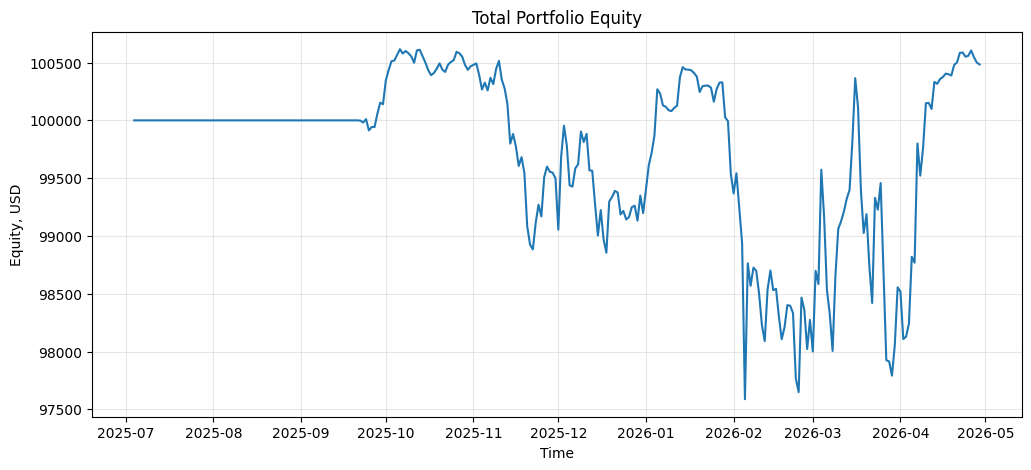

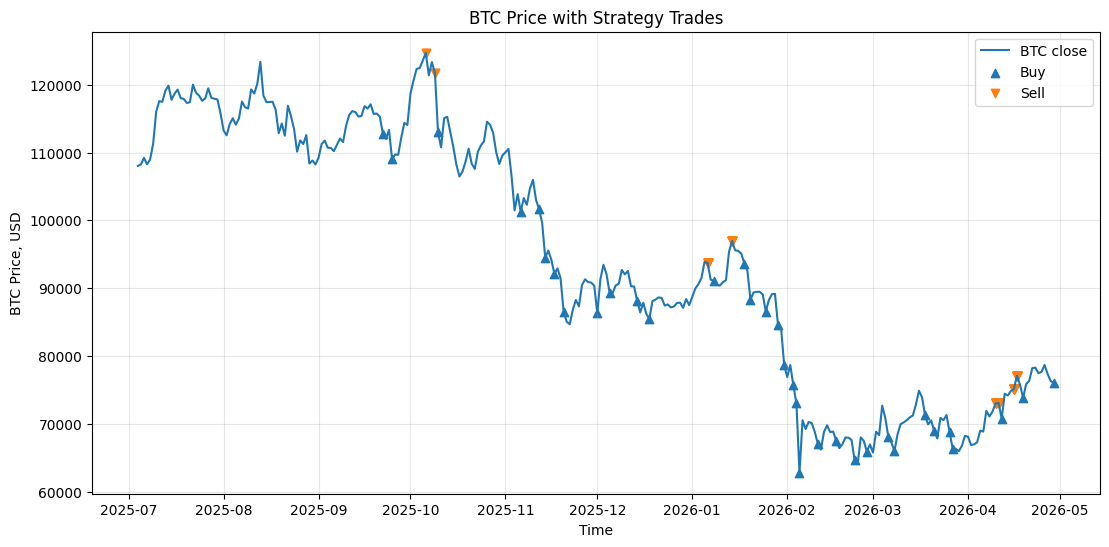

In [23]:
# Plot final results
plot_equity_curve(equity_df)
plot_price_with_trades(df, buys_df, sells_df)